In [1]:

import os
import pandas
import datetime

import new_artist as artist

import data_pers
import plots
from plots import *
from read_data import *


from useful import rexp, format_timedelta

from numpy import array, log, exp, mean, std, linspace

from scipy import stats



/home/shubin/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shubin/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
data = pandas.read_csv('data/data.csv')
data

,Unnamed: 0,x_lon,y_lat,year,country,HaulNumber,doty,trawl_depth,trawl_dur,trawl_net,...,254529,154675,127190,127187,105923,127137,126281,126916,126437,151308
0,0,19.4613,63.1488,2007,SE,1,274,40.0,30,16.0,...,0,0,0,0,0,0,0,0,0,0
1,1,18.8120,62.4123,2007,SE,10,275,80.0,31,15.0,...,0,0,0,0,0,0,0,0,0,0
2,2,19.4040,62.4060,2007,SE,11,275,63.6,60,13.4,...,0,0,0,0,0,0,0,0,0,0
3,3,20.3698,62.3898,2007,SE,12,275,2.4,30,17.6,...,0,0,0,0,0,0,0,0,0,0
4,4,19.1682,62.0292,2007,SE,13,276,14.6,30,18.5,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2532,2532,16.2200,55.2500,2023,PL,23,274,54.0,30,16.0,...,0,0,0,0,0,0,0,0,0,0
2533,2533,16.2700,55.1100,2023,PL,24,274,50.5,30,16.0,...,0,0,0,0,0,0,0,0,0,0
2534,2534,16.3600,54.7200,2023,PL,25,275,21.5,30,14.0,...,0,0,0,0,0,0,0,0,0,0
2535,2535,16.6900,55.2700,2023,PL,26,275,51.5,30,16.0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
SP = DictOfUsedFish()
list(SP)

[her	126417	Atlantic herring,
 spr	126425	European sprat,
 stb	126505	Threespine stickleback,
 cod	126436	Atlantic cod,
 stb9	126507	Ninespine Stickleback,
 lumpf	127214	Lumpfish,
 whit	126438	Whiting,
 ach	126426	European anchovy,
 pom	125999	Goby,
 makr	126822	Atlantic horse mackerel,
 flo	127141	European flounder,
 smelt	126736	European smelt,
 dab	127139	Common dab,
 tgoby	126868	Transparent goby,
 pip	127385	Straightnose pipefish,
 wee	127082	Greater weever,
 snail	127219	Sea snail,
 amakr	127023	Atlantic mackerel,
 eel	126756	Great sand eel,
 pla	127143	European plaice,
 sal	127186	Salmon,
 eelpout	127123	European eelpout,
 gurnard	150637	Grey gurnard,
 rout	127203	Shorthorn sculpin,
 garf	126375	Garfish,
 lamprey	101172	European river lamprey,
 wrasse	126964	Goldsinny wrasse,
 sard	126421	European sardine,
 bgoby	126892	Black goby,
 fangtooth	127393	Common fangtooth,
 lse	126752	Lesser sand eel ,
 hake	126484	European hake,
 turbot	127149	Turbot,
 rock	126450	Fourbeard rockling,

In [4]:
DATA = data[[str(SP[x].code) for x in SP]]
DATA

,126417,126425,126505,126436,126507,127214,126438,126426,125999,126822,...,254529,154675,127190,127187,105923,127137,126281,126916,126437,151308
0,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2532,1,1,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2533,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2534,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2535,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
DATA_H = data.groupby(['country', 'year']).max().reset_index()[[str(x) for x in SP.code]].copy()
DATA_H

,126417,126425,126505,126436,126507,127214,126438,126426,125999,126822,...,254529,154675,127190,127187,105923,127137,126281,126916,126437,151308
0,1,1,1,1,0,1,1,1,1,1,...,0,0,1,0,1,0,1,0,0,1
1,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,1,0,0,1
2,1,1,1,1,0,1,1,1,1,1,...,0,0,1,1,1,1,1,0,0,1
3,1,1,1,1,0,1,1,1,1,1,...,0,0,1,1,0,0,0,0,0,1
4,1,1,1,1,0,1,1,1,1,1,...,0,0,1,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,1,1,1,1,1,1,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
80,1,1,1,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
81,1,1,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
82,1,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
h = (DATA > 0).sum().sort_values()

list_of_s = list(h.index)[::-1]

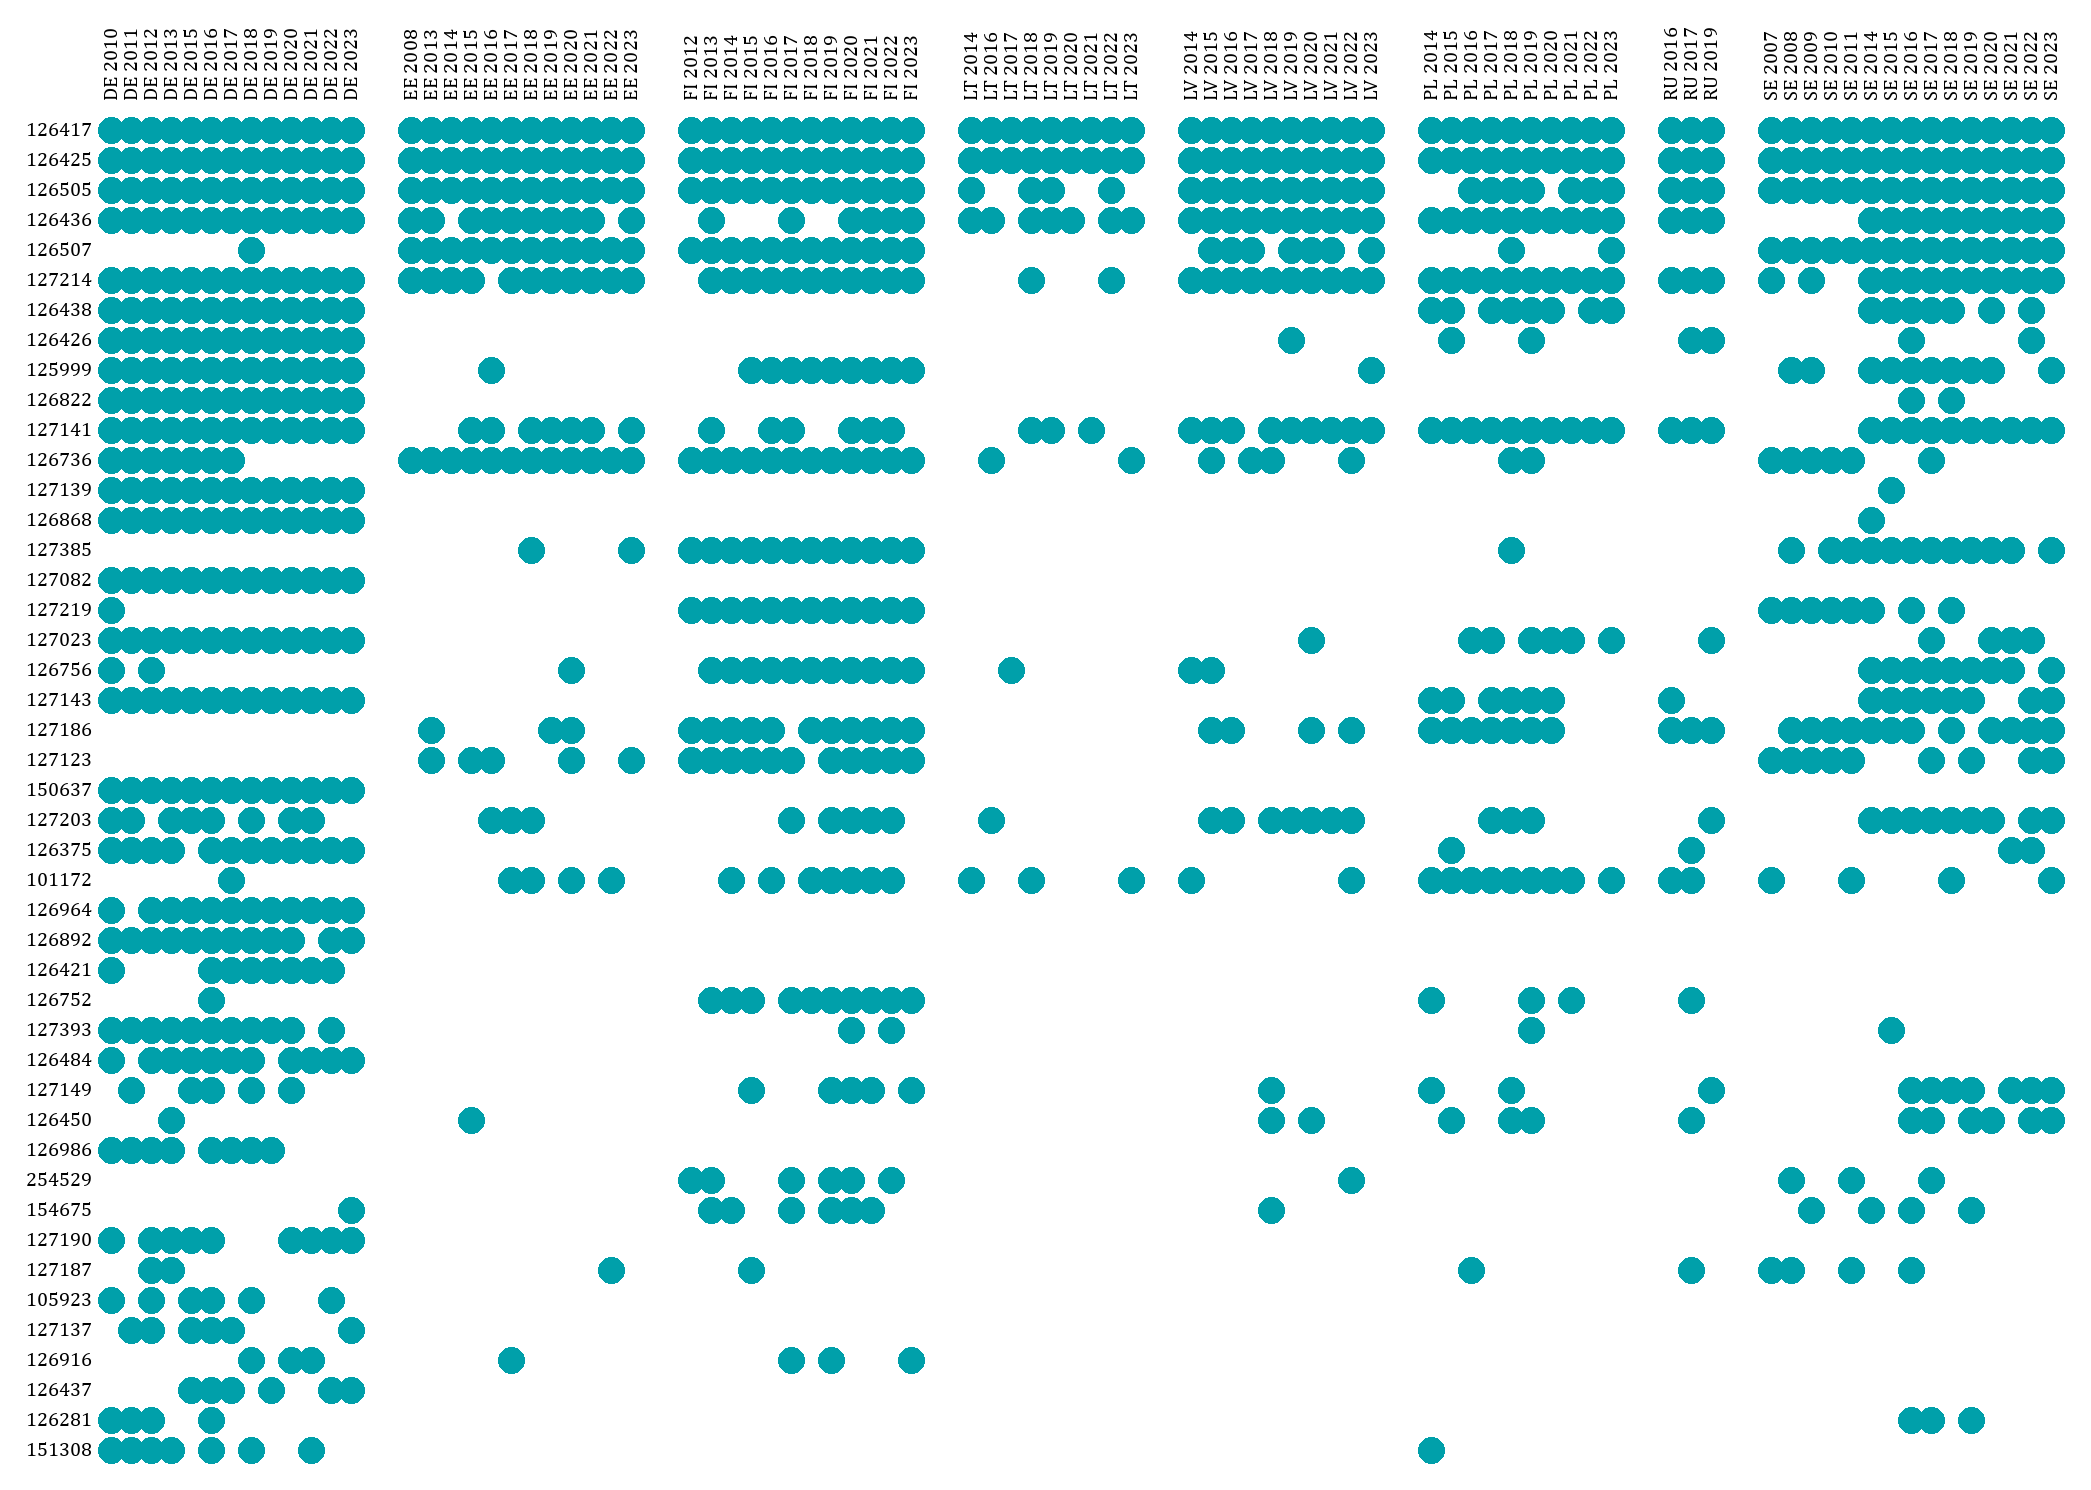

In [7]:
P = artist.Panel()
P.Y.k=30
P.X.k=20
i = 0


for _, c in enumerate(sorted(data.country.unique())):
    subdata = data[data.country == c]
    for _, year in enumerate(sorted(subdata.year.unique())):
        P.text(i, 1, f'{c} {year}', pos='^.', z=1, font=20)
        ssubdata = subdata[subdata.year == year]

        for j, s in enumerate(list_of_s):
            x = ssubdata[s].sum()
            if x > 0:
                P.circle(i, -j, r=13, col='c')
        i += 1
    i += 2

for j, s in enumerate(list_of_s):
    P.text(-1, -j, str(s), pos='<.', z=1, font=20)
            
P.show()

In [8]:
len(SP)

45

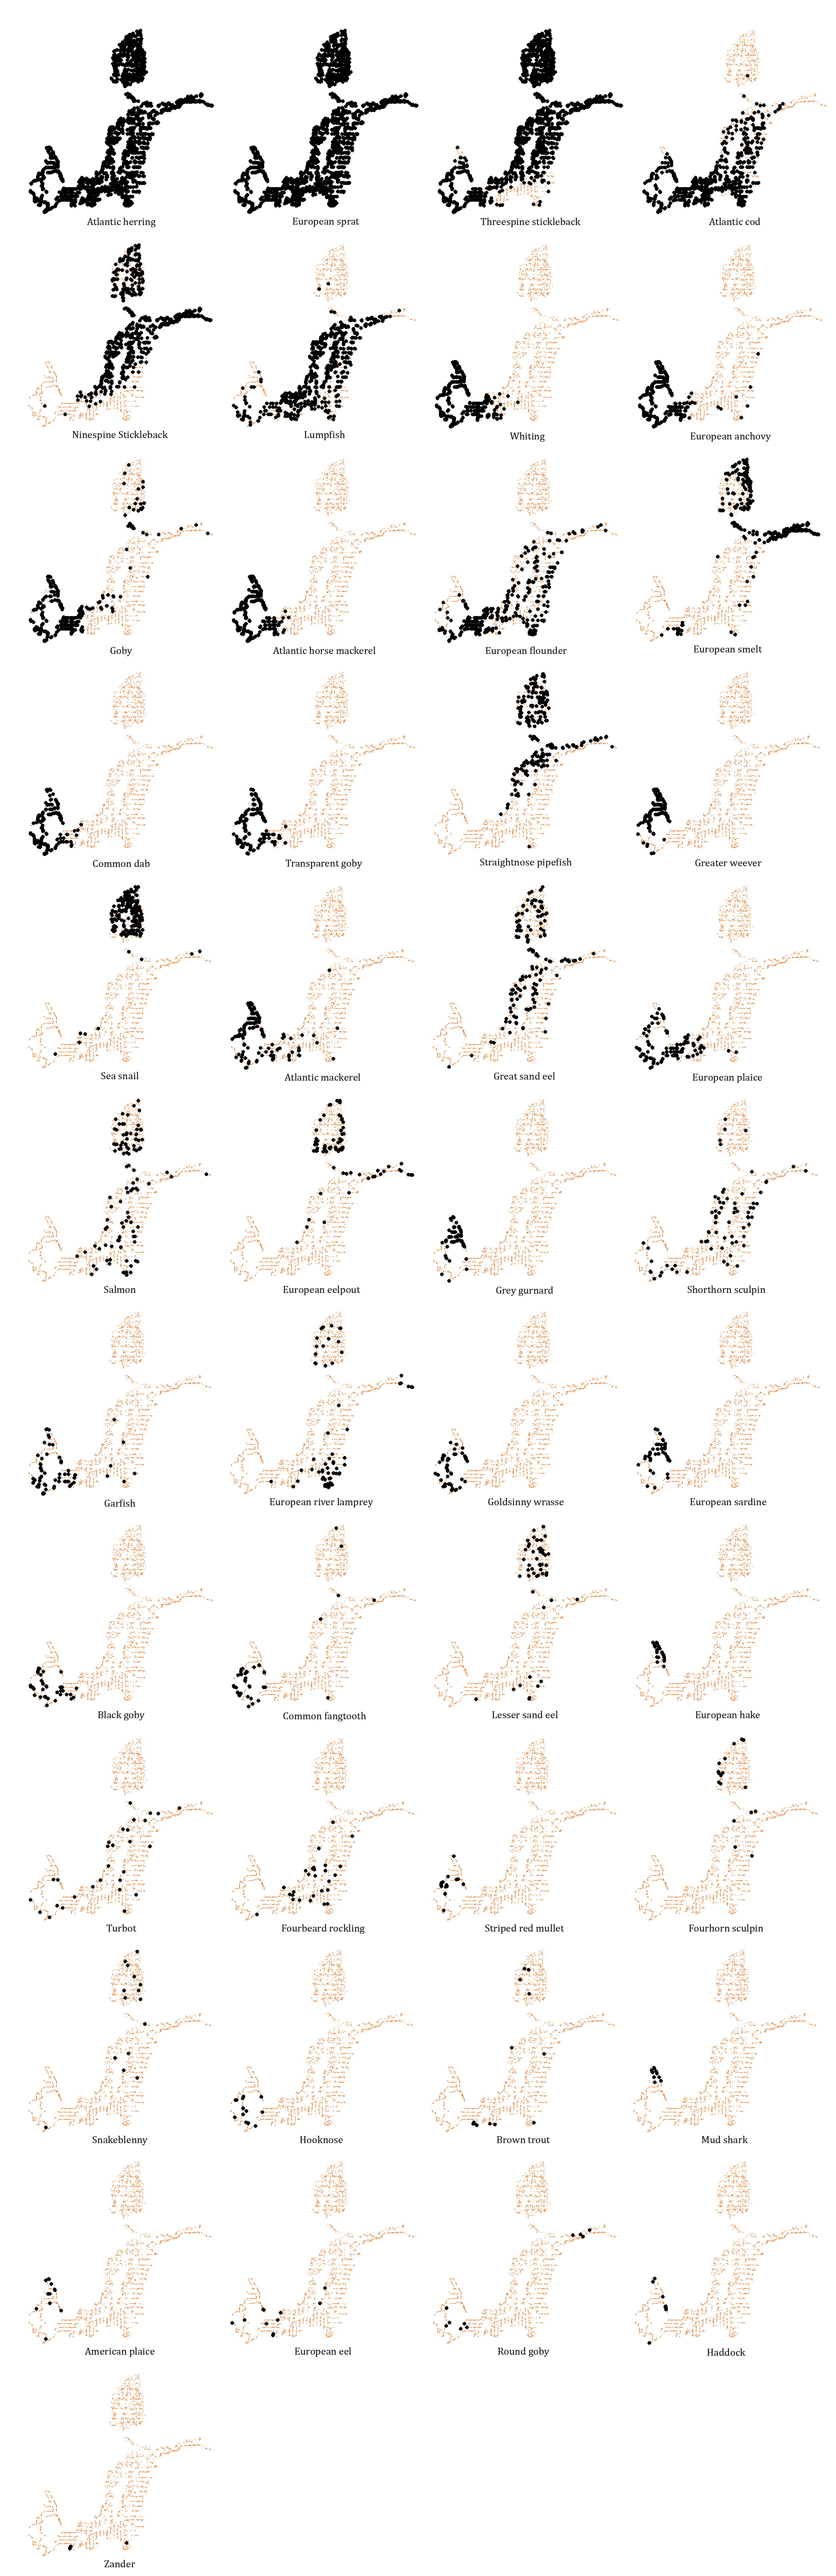

In [9]:

def splot(s):
    P = artist.Panel(500, 500) 
    P.points(data.x_lon, data.y_lat, col='o', p=1)
    subdata = data[data[str(SP[s].code)]==1]
    P.points(subdata.x_lon, subdata.y_lat, col='k', p=9)
    P.bottom = SP[s].name
    return P

def multyplot():
    PPPP = artist.Panel()
    PPP = artist.Panel()
    for i, n in enumerate(SP):
        PPP += splot(n)
        if (i+1) % 4 == 0:
            PPPP /= PPP
            PPP = artist.Panel()
    PPPP /= PPP
    return PPPP.show()

multyplot()

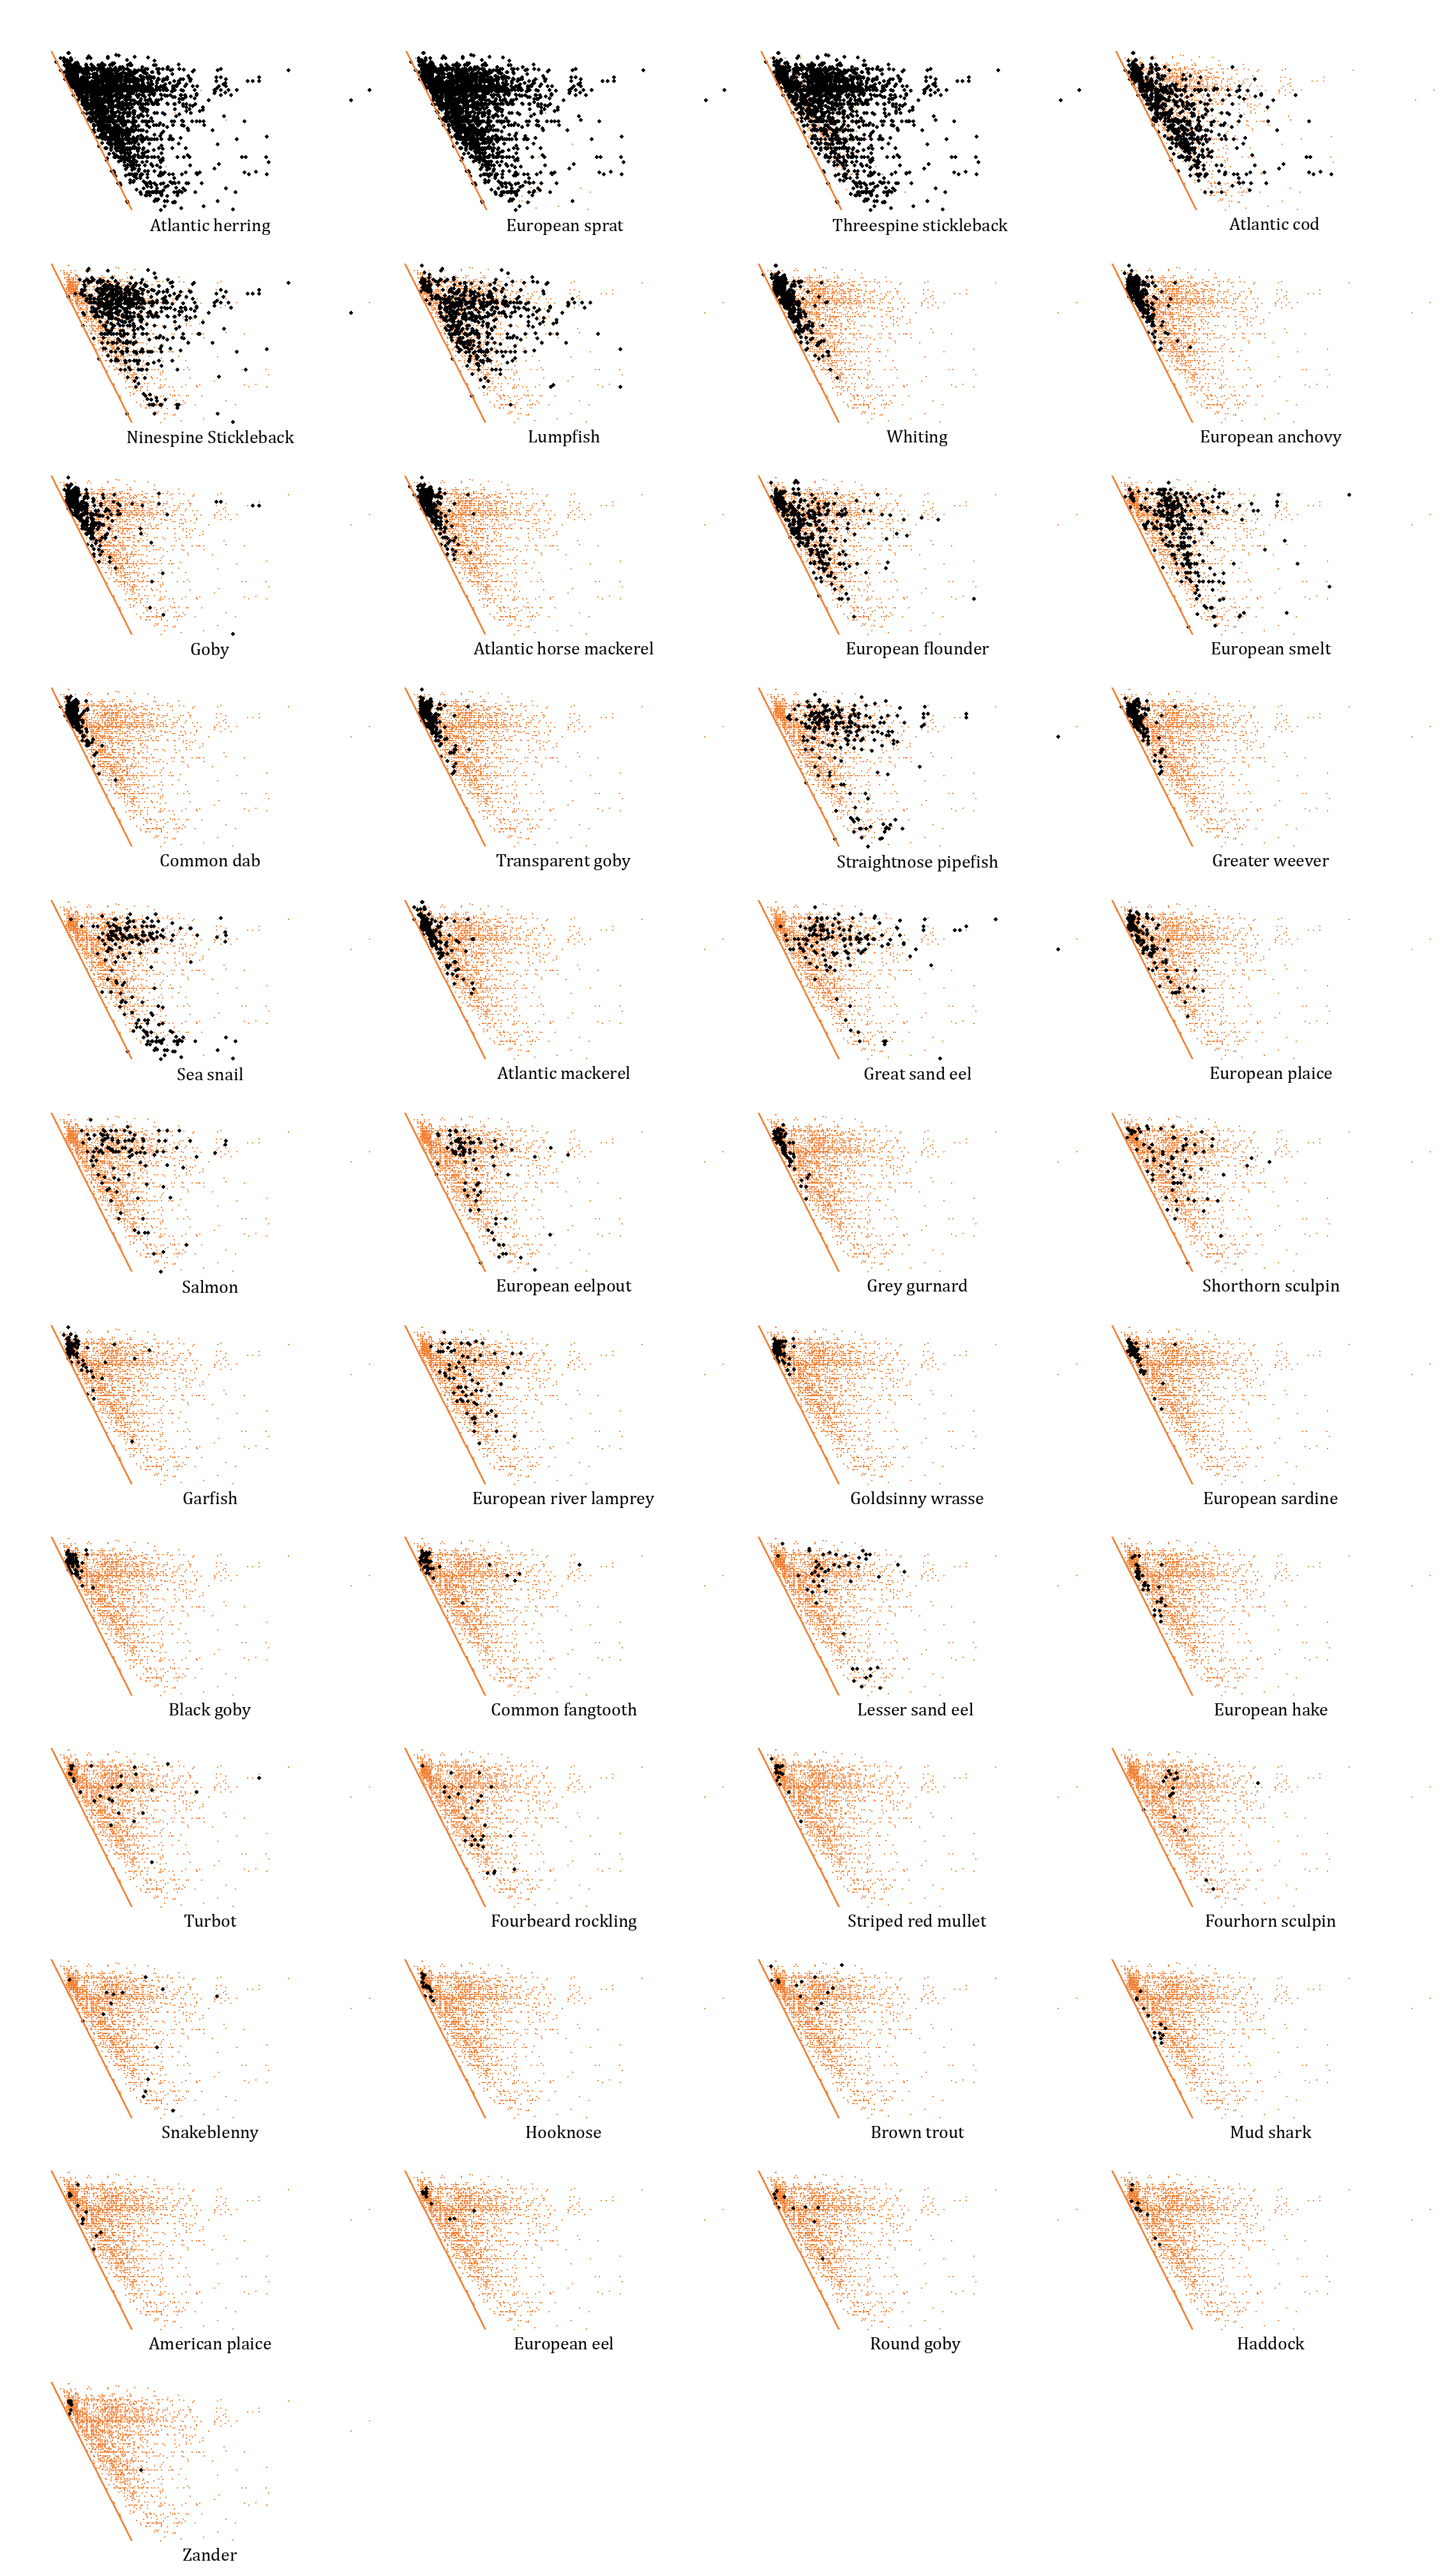

In [10]:

def splot(s):
    P = artist.Panel(500, 250) 
    P.points(data.depth, -data.trawl_depth, col='o', p=1)
    subdata = data[data[str(SP[s].code)]==1]
    P.points(subdata.depth, -subdata.trawl_depth, col='k', p=5)
    P.bottom = SP[s].name
    P.lines([0, 90], [0, -90], col='o')
    return P


multyplot()

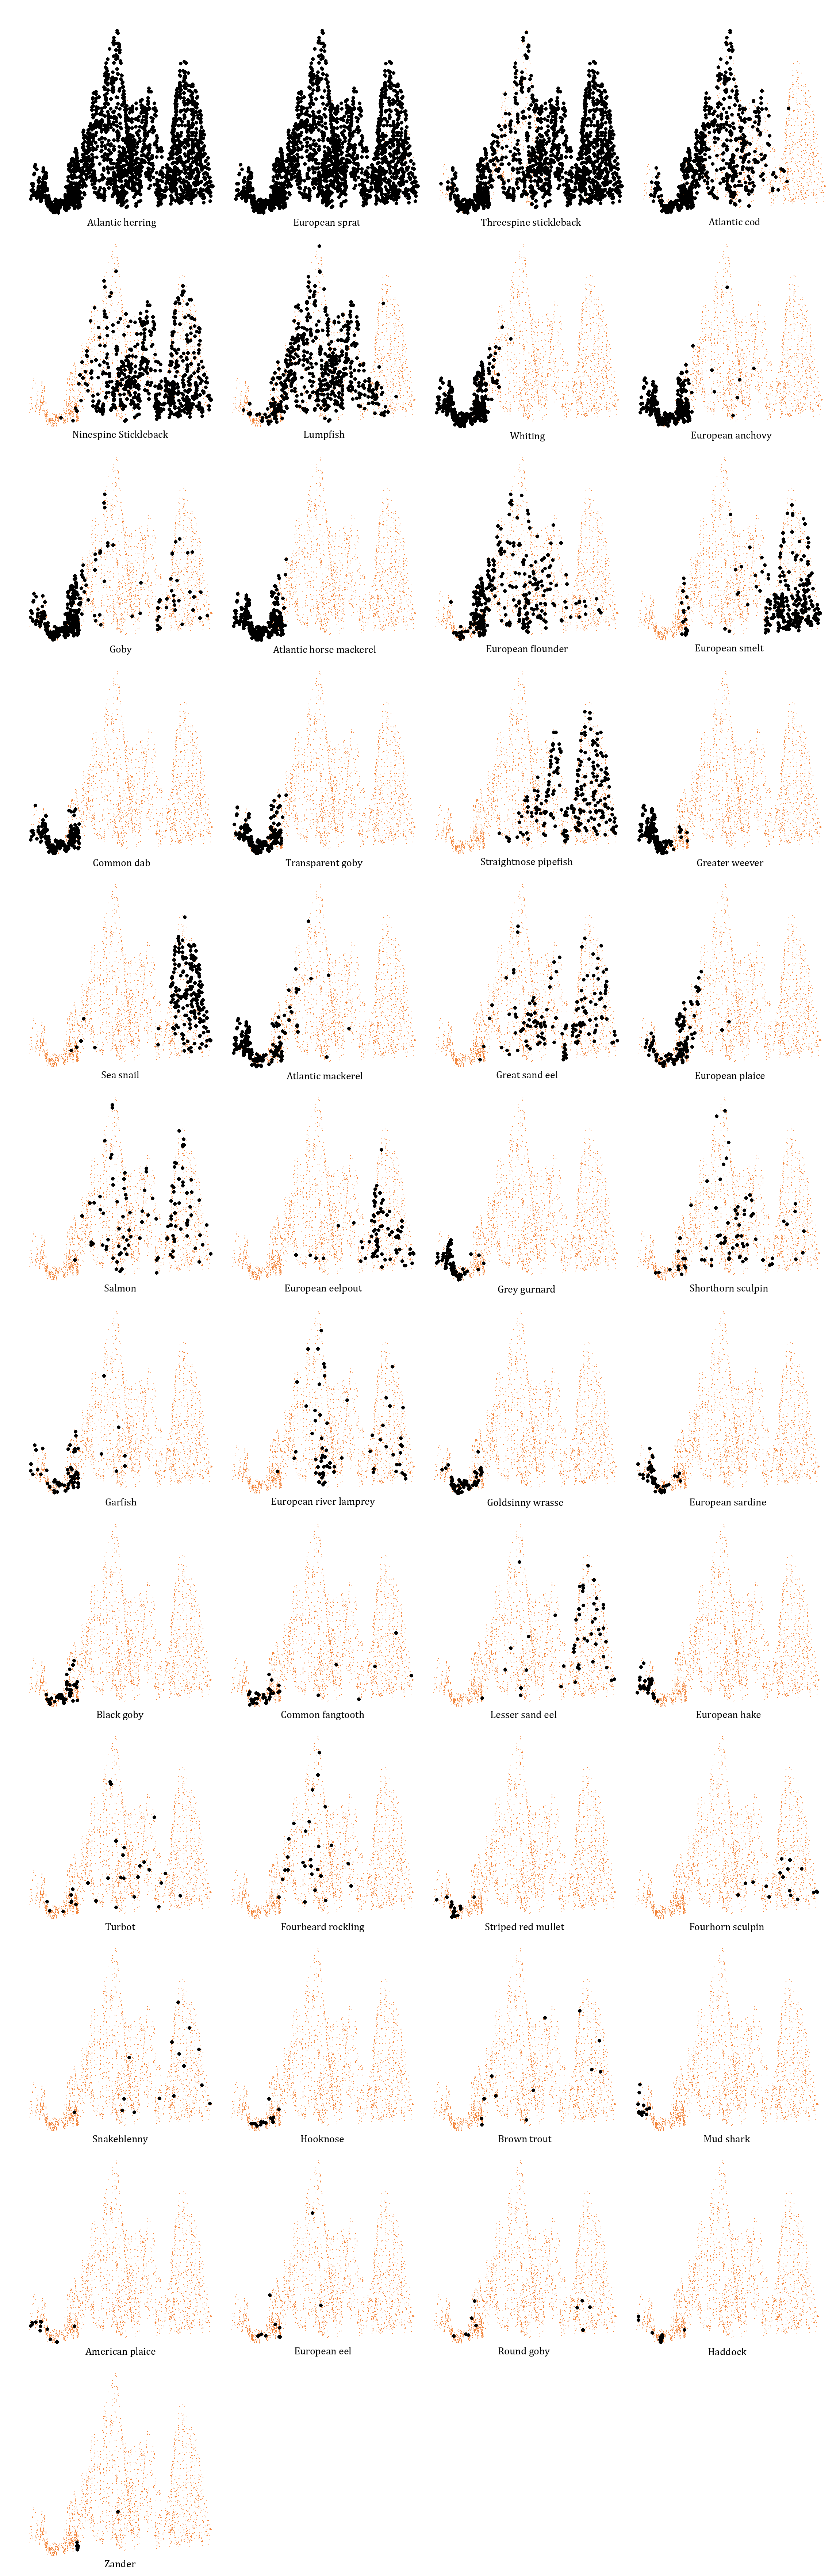

In [11]:
def splot(s):
    P = artist.Panel(500, 500) 
    P.points(data.dto, data.dts, col='o', p=1)
    subdata = data[data[str(SP[s].code)]==1]
    P.points(subdata.dto, subdata.dts, col='k', p=9)
    P.bottom = SP[s].name
    return P


multyplot()